# Obesity Levels Classifier — Full Analysis

End-to-end notebook: data validation -> EDA -> baseline models -> hyperparameter tuning -> explainability & error analysis -> final model. All stages live here in one notebook, run top to bottom.

# 01 — Data Analysis: Validation, Cleaning, Feature Analysis

Inspects the raw dataset, validates it, documents cleaning decisions, and
defines the two feature configurations used throughout the project.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
from data_validation import validate_dataset, print_validation_report
from preprocessing import load_and_clean_data, compute_bmi, TARGET_COLUMN, FULL_CONFIG, LIFESTYLE_CONFIG

pd.set_option('display.max_columns', None)


## 1. Load raw data

In [2]:
df_raw = pd.read_csv('../data/obesity_data.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

## 2. Validation checks

In [4]:
report = validate_dataset(df_raw)
print_validation_report(report)


DATA VALIDATION REPORT

Missing values:
  None found.

Duplicate rows: 24

Unexpected categorical values:
  None found. All categories match expected values.

Numerical values out of plausible range:
  None found.

Non-positive Height/Weight rows: 0

Target classes found (7):
  - Insufficient_Weight: 272 records
  - Normal_Weight: 287 records
  - Obesity_Type_I: 351 records
  - Obesity_Type_II: 297 records
  - Obesity_Type_III: 324 records
  - Overweight_Level_I: 290 records
  - Overweight_Level_II: 290 records


### Findings
- No missing values.
- No unexpected/invalid categorical values — every column matches its expected set exactly.
- No numerical values outside plausible physical ranges.
- **24 exact duplicate rows** — the only issue found.
- Target has exactly the 7 expected classes, reasonably balanced (272–351 records each).

### Cleaning decision
Exact duplicate rows are dropped. They add no new information for training
and would otherwise slightly bias class frequencies. No other rows are
modified or removed — nothing else in the data looked suspicious or invalid.

In [5]:
df = load_and_clean_data('../data/obesity_data.csv')
print(f"Clean shape: {df.shape}")
df.describe().T


[load_and_clean_data] Dropped 24 exact duplicate rows (2111 -> 2087).
Clean shape: (2087, 17)


,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.353090,6.368801,14.00,19.915937,22.847618,26.000000,61.00
Height,2087.0,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,86.858730,26.190847,39.00,66.000000,83.101100,108.015907,173.00
FCVC,2087.0,2.421466,0.534737,1.00,2.000000,2.396265,3.000000,3.00
NCP,2087.0,2.701179,0.764614,1.00,2.697467,3.000000,3.000000,4.00
CH2O,2087.0,2.004749,0.608284,1.00,1.590922,2.000000,2.466193,3.00
FAF,2087.0,1.012812,0.853475,0.00,0.124505,1.000000,1.678102,3.00
TUE,2087.0,0.663035,0.608153,0.00,0.000000,0.630866,1.000000,2.00


## 3. Feature type analysis

In [6]:
print("Numerical features:", FULL_CONFIG.numerical)
print("Nominal categorical features:", FULL_CONFIG.nominal)
print("Ordinal categorical features:", FULL_CONFIG.ordinal, "(order: no < Sometimes < Frequently < Always)")


Numerical features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Nominal categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']
Ordinal categorical features: ['CAEC', 'CALC'] (order: no < Sometimes < Frequently < Always)


### Potentially redundant / target-defining features

**Height and Weight** are body measurements directly related to how the
target classes are defined (obesity classification is fundamentally a
function of BMI = Weight / Height^2, thresholded into 7 bands). This does
not automatically make them "leakage" in the strict sense — they are raw
measurements, not the target label itself, and a real-world prediction
system might reasonably have access to them. But their relationship to the
target is much more direct than genuinely independent lifestyle signals
(diet, activity, transport, etc).

To handle this rigorously rather than assuming an answer, two feature
configurations are defined and will be compared empirically in the modeling
stage:

In [7]:
print("FULL feature config:")
print(f"  {FULL_CONFIG.all_features}")
print(f"  ({len(FULL_CONFIG.all_features)} features)\n")

print("LIFESTYLE-FOCUSED feature config (no Height/Weight):")
print(f"  {LIFESTYLE_CONFIG.all_features}")
print(f"  ({len(LIFESTYLE_CONFIG.all_features)} features)")


FULL feature config:
  ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS', 'CAEC', 'CALC']
  (16 features)

LIFESTYLE-FOCUSED feature config (no Height/Weight):
  ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS', 'CAEC', 'CALC']
  (14 features)


## 4. BMI — exploratory only

In [8]:
df['BMI'] = compute_bmi(df)
order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
df.groupby(TARGET_COLUMN)['BMI'].describe().loc[order]


,count,mean,std,min,25%,50%,75%,max
NObeyesdad,,,,,,,,
Insufficient_Weight,267.0,17.390730,0.787144,12.998685,17.070307,17.532455,17.895399,19.082206
Normal_Weight,282.0,22.007841,1.848433,18.491124,20.592287,22.122809,23.700195,24.913495
Overweight_Level_I,276.0,25.956179,0.658815,22.826739,25.555096,25.951557,26.312334,28.769607
Overweight_Level_II,290.0,28.215232,0.827862,25.713513,27.612992,28.152417,28.889196,30.362877
Obesity_Type_I,351.0,32.255636,1.130957,29.911958,31.370619,32.200035,32.973741,35.171095
Obesity_Type_II,297.0,36.723424,1.290127,34.048509,35.750525,36.417803,37.880693,39.786652
Obesity_Type_III,324.0,42.273746,2.578689,36.774400,40.591185,41.942617,43.838604,50.811753


BMI ranges are almost perfectly separated by class, which is expected since
the target's own class definitions are BMI-threshold-based. Including BMI as
a predictive feature would make the task closer to re-deriving the target's
definition rather than learning genuinely predictive relationships, so BMI
is **not** included in either feature configuration — it is used here for
analysis only.

## 5. Summary

- Cleaned dataset: 2,087 rows x 17 columns (24 duplicates removed), no missing values, no invalid categories.
- Two feature configurations defined: `full` (16 features) and `lifestyle` (14 features, no Height/Weight).
- BMI computed for exploratory purposes only, excluded from modeling.
- Proceed to `02_eda.ipynb` for visual exploratory analysis.

# 02 — Exploratory Data Analysis (Visualizations)

In [9]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import load_and_clean_data, compute_bmi, TARGET_COLUMN

plt.rcParams['figure.dpi'] = 100

df = load_and_clean_data('../data/obesity_data.csv')
df['BMI'] = compute_bmi(df)

order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']


[load_and_clean_data] Dropped 24 exact duplicate rows (2111 -> 2087).


## 1. Target class distribution

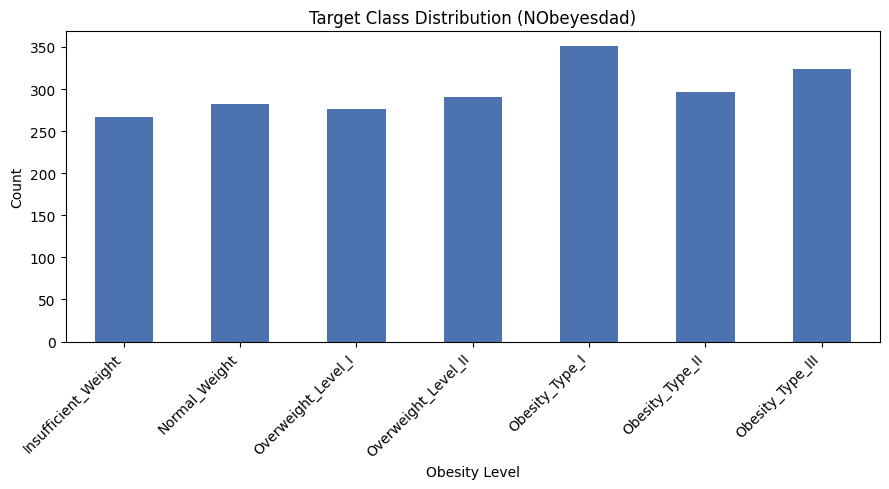

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
df[TARGET_COLUMN].value_counts().loc[order].plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Target Class Distribution (NObeyesdad)')
ax.set_xlabel('Obesity Level')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/target_distribution.png')
plt.show()


## 2. Age, weight, and height distributions

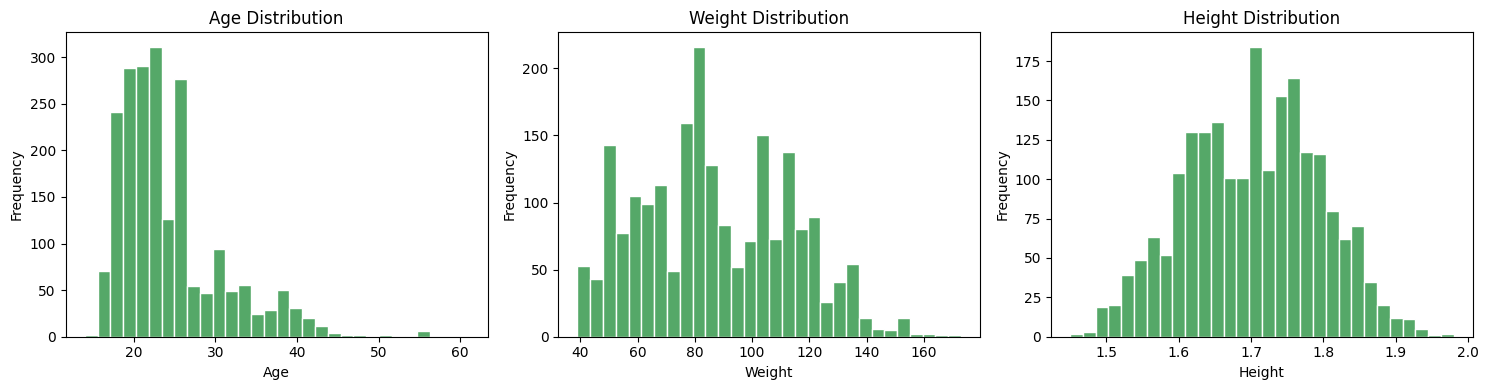

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Weight', 'Height']):
    ax.hist(df[col], bins=30, color='#55A868', edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../reports/numerical_distributions.png')
plt.show()


## 3. Obesity level vs. Age and Weight

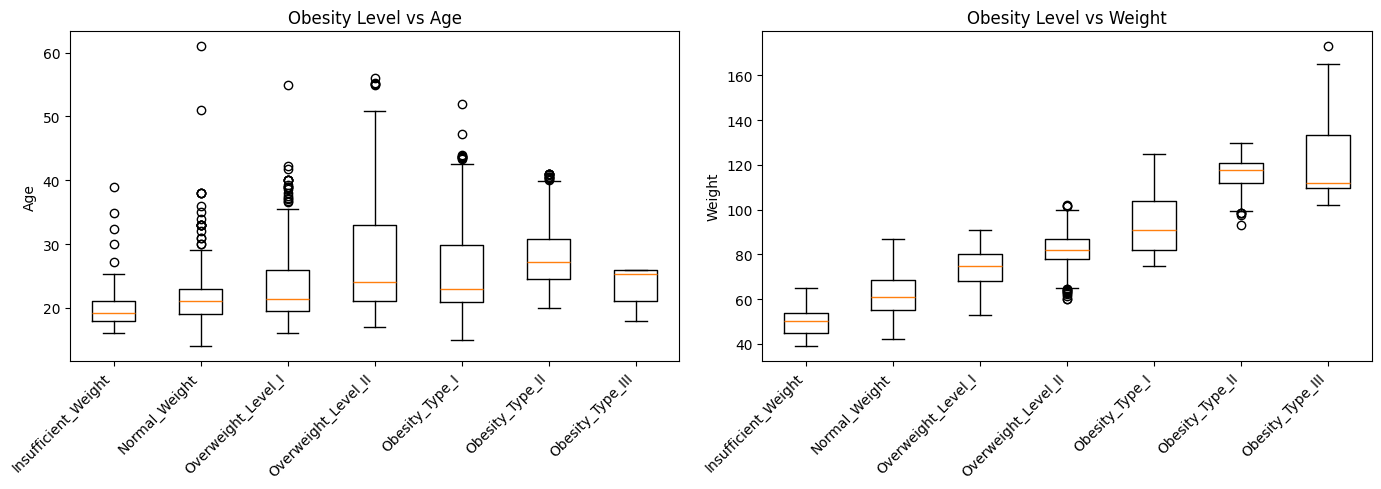

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['Age', 'Weight']):
    data_by_class = [df[df[TARGET_COLUMN] == cls][col].values for cls in order]
    ax.boxplot(data_by_class, tick_labels=order)
    ax.set_title(f'Obesity Level vs {col}')
    ax.set_ylabel(col)
    ax.set_xticklabels(order, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/obesity_vs_age_weight.png')
plt.show()


**Observation:** Weight has a strong, near-monotonic relationship with obesity class (expected, since it partly defines the class). Age shows a weaker upward trend.

## 4. Obesity level vs. physical activity and high-calorie food

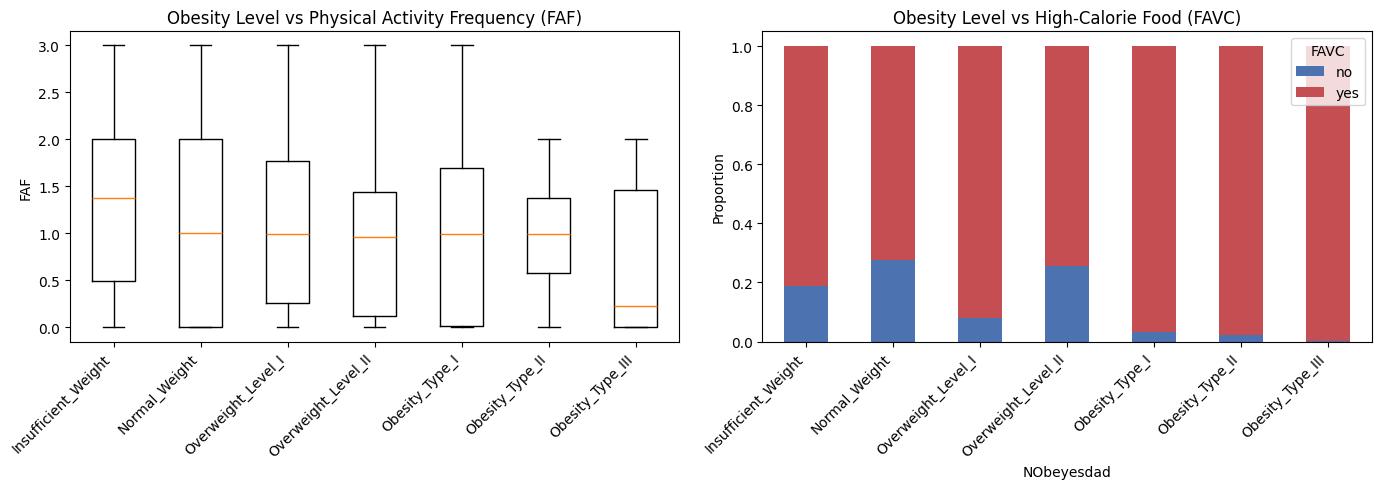

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_by_class = [df[df[TARGET_COLUMN] == cls]['FAF'].values for cls in order]
axes[0].boxplot(data_by_class, tick_labels=order)
axes[0].set_title('Obesity Level vs Physical Activity Frequency (FAF)')
axes[0].set_ylabel('FAF')
axes[0].set_xticklabels(order, rotation=45, ha='right')

ct = pd.crosstab(df[TARGET_COLUMN], df['FAVC'], normalize='index').loc[order]
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#C44E52'])
axes[1].set_title('Obesity Level vs High-Calorie Food (FAVC)')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(order, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../reports/obesity_vs_faf_favc.png')
plt.show()


**Observation:** Physical activity (FAF) trends downward for higher obesity classes. Frequent high-calorie food consumption (FAVC) is more common among higher obesity classes.

## 5. Obesity level vs. vegetable consumption and technology usage

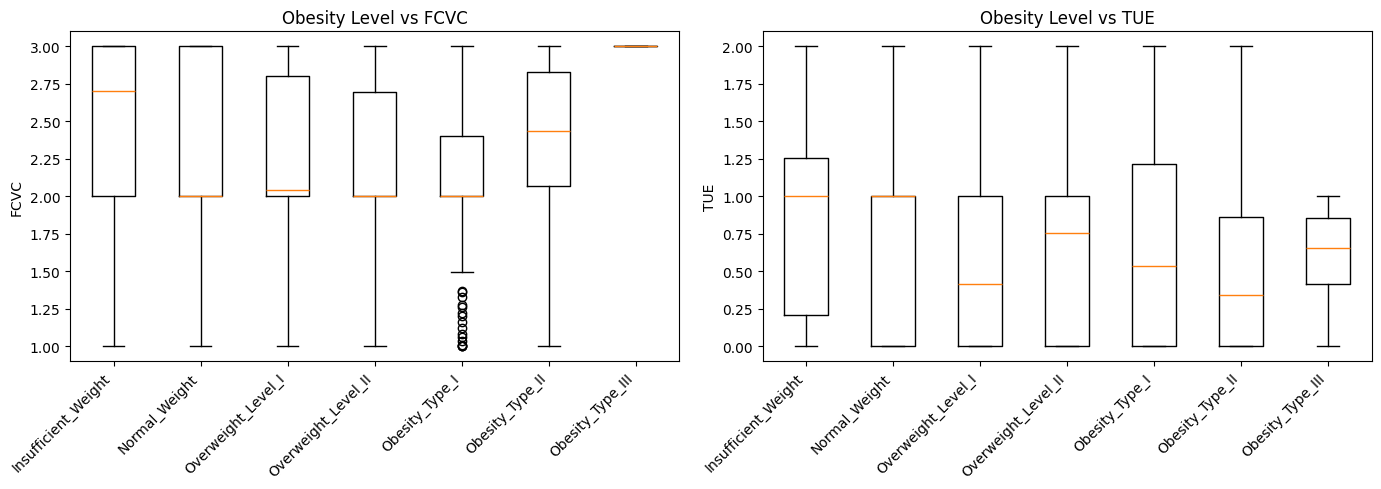

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['FCVC', 'TUE']):
    data_by_class = [df[df[TARGET_COLUMN] == cls][col].values for cls in order]
    ax.boxplot(data_by_class, tick_labels=order)
    ax.set_title(f'Obesity Level vs {col}')
    ax.set_ylabel(col)
    ax.set_xticklabels(order, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/obesity_vs_fcvc_tue.png')
plt.show()


## 6. Categorical lifestyle variables vs. target

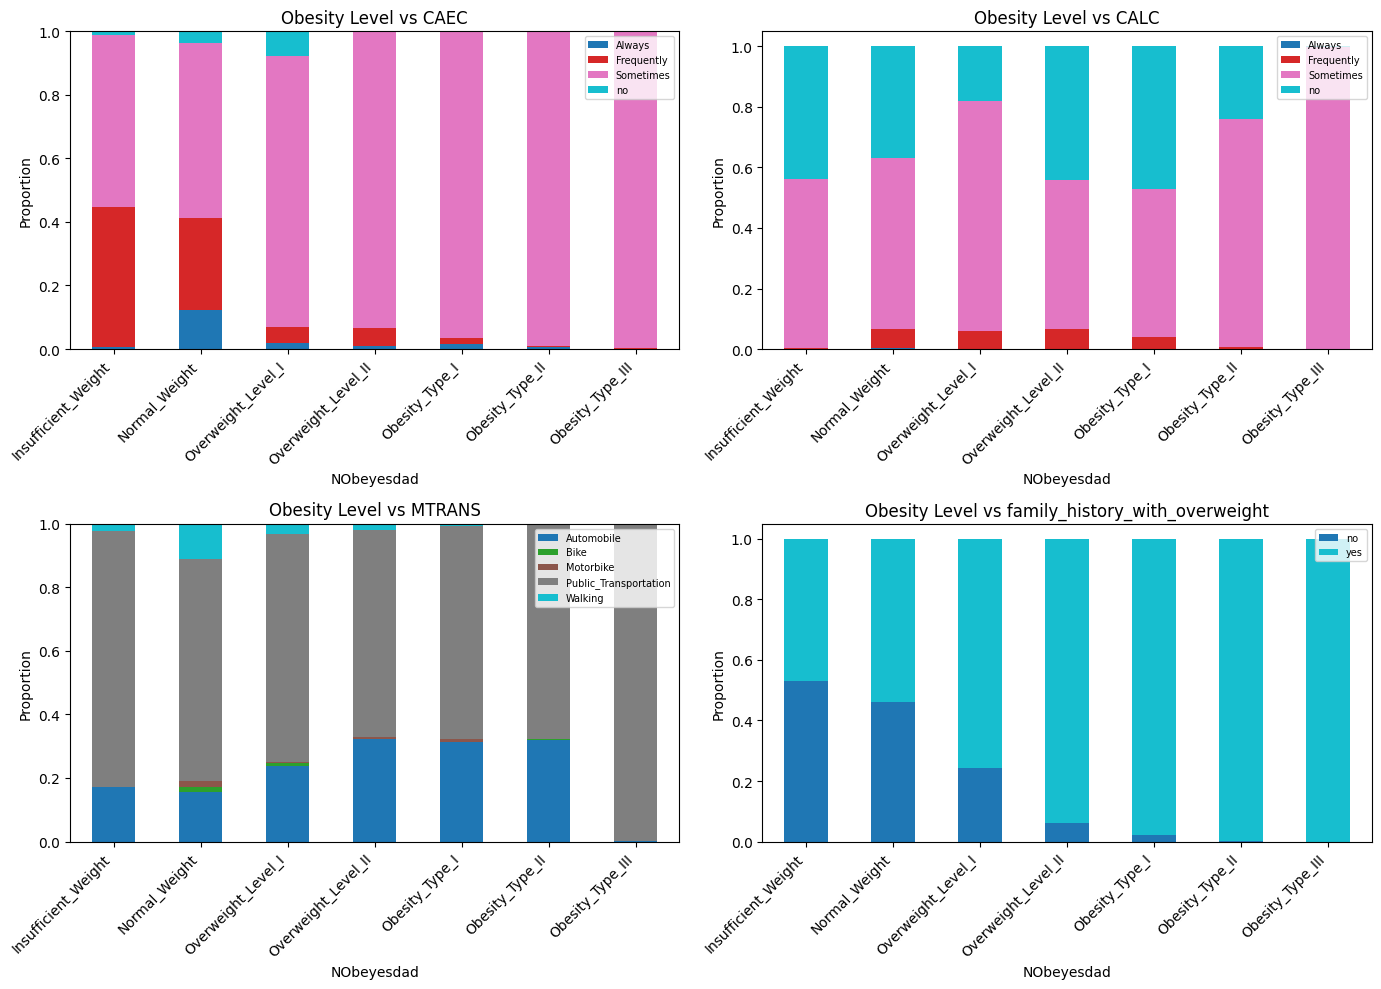

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ['CAEC', 'CALC', 'MTRANS', 'family_history_with_overweight']):
    ct = pd.crosstab(df[TARGET_COLUMN], df[col], normalize='index').loc[order]
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', legend=True)
    ax.set_title(f'Obesity Level vs {col}')
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(order, rotation=45, ha='right')
    ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig('../reports/obesity_vs_categorical.png')
plt.show()


**Observation:** `family_history_with_overweight = yes` is markedly more common in higher obesity classes. `CAEC` (eating between meals) and `MTRANS` (transport) also show visible shifts across classes.

## 7. Numerical correlation heatmap

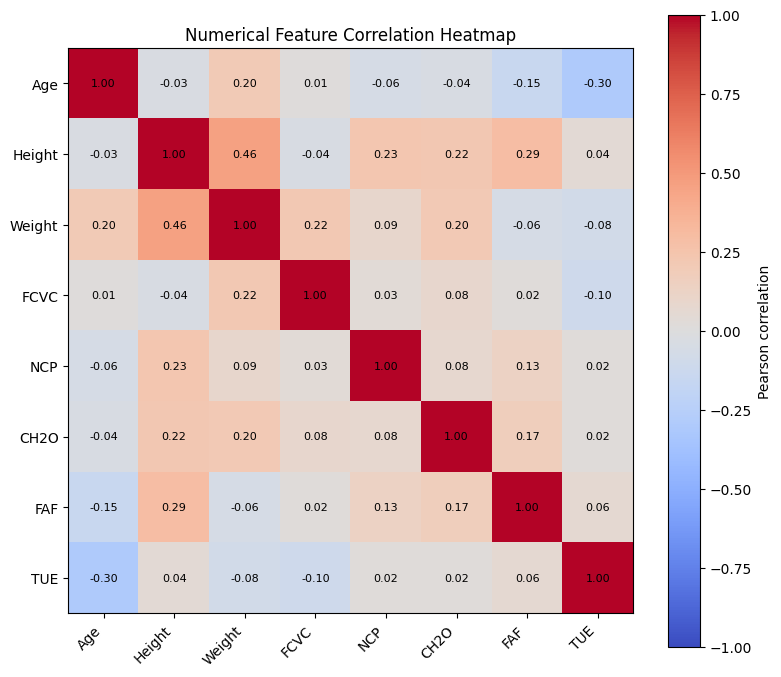

In [16]:
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
corr = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numerical_cols)))
ax.set_yticks(range(len(numerical_cols)))
ax.set_xticklabels(numerical_cols, rotation=45, ha='right')
ax.set_yticklabels(numerical_cols)
for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
ax.set_title('Numerical Feature Correlation Heatmap')
fig.colorbar(im, ax=ax, label='Pearson correlation')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()


No pair of numerical features (other than Height/Weight, moderately correlated as expected) shows strong multicollinearity — no features are dropped on this basis.

## 8. Summary of EDA findings

- Target classes are reasonably balanced.
- Weight is the strongest single visible predictor of obesity class (expected).
- Lifestyle signals (FAF, FAVC, FCVC, family history, CAEC) all show visible, plausible trends across classes.
- No missing-data or multicollinearity issues that require feature removal beyond the Height/Weight investigation already covered in notebook 01.
- Ready to proceed to preprocessing pipeline construction and model training.

# 03 — Baseline Model Training & Comparison

Trains 5 baseline classifiers (Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost) on both feature configurations (full vs lifestyle-focused), using Stratified 5-Fold Cross-Validation on the training set and a held-out test set for final evaluation. All preprocessing (scaling/encoding) is fit only inside each pipeline's CV folds — never on the full dataset ahead of time — to avoid leakage.

In [17]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from preprocessing import load_and_clean_data, FULL_CONFIG, LIFESTYLE_CONFIG
from train import run_experiment

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

In [18]:
df = load_and_clean_data('../data/obesity_data.csv')

label_encoder = LabelEncoder()
label_encoder.fit(df['NObeyesdad'])
print('Classes:', list(label_encoder.classes_))

[load_and_clean_data] Dropped 24 exact duplicate rows (2111 -> 2087).
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## 1. Experiment A: Full feature set (includes Height/Weight)

In [19]:
results_full = run_experiment(df, FULL_CONFIG, label_encoder)

  [full] Logistic Regression: CV Macro-F1=0.8624 | Test Macro-F1=0.8781 | 0.7s


  [full] Decision Tree: CV Macro-F1=0.9155 | Test Macro-F1=0.9333 | 0.3s


  [full] Random Forest: CV Macro-F1=0.9367 | Test Macro-F1=0.9508 | 3.8s


  [full] SVM: CV Macro-F1=0.8880 | Test Macro-F1=0.9052 | 2.3s


  [full] XGBoost: CV Macro-F1=0.9591 | Test Macro-F1=0.9683 | 2.0s


## 2. Experiment B: Lifestyle-focused feature set (no Height/Weight)

In [20]:
results_lifestyle = run_experiment(df, LIFESTYLE_CONFIG, label_encoder)

  [lifestyle] Logistic Regression: CV Macro-F1=0.5478 | Test Macro-F1=0.5390 | 0.7s


  [lifestyle] Decision Tree: CV Macro-F1=0.7438 | Test Macro-F1=0.7283 | 0.3s


  [lifestyle] Random Forest: CV Macro-F1=0.8332 | Test Macro-F1=0.8429 | 3.8s


  [lifestyle] SVM: CV Macro-F1=0.7269 | Test Macro-F1=0.7454 | 2.7s


  [lifestyle] XGBoost: CV Macro-F1=0.8309 | Test Macro-F1=0.8355 | 2.8s


## 3. Combined comparison

In [21]:
all_results = pd.concat([results_full, results_lifestyle], ignore_index=True)
all_results = all_results.sort_values('cv_f1_macro', ascending=False)
display_cols = ['model', 'feature_config', 'cv_accuracy', 'cv_f1_macro',
                 'test_accuracy', 'test_f1_macro', 'test_f1_weighted', 'train_time_sec']
all_results[display_cols]

,model,feature_config,cv_accuracy,cv_f1_macro,test_accuracy,test_f1_macro,test_f1_weighted,train_time_sec
4,XGBoost,full,0.960456,0.959122,0.968900,0.968296,0.968935,2.00
2,Random Forest,full,0.938886,0.936710,0.952153,0.950849,0.952761,3.81
1,Decision Tree,full,0.917301,0.915472,0.935407,0.933257,0.935103,0.27
3,SVM,full,0.892742,0.887956,0.909091,0.905161,0.909288,2.32
0,Logistic Regression,full,0.868170,0.862377,0.885167,0.878094,0.882222,0.71
7,Random Forest,lifestyle,0.837626,0.833175,0.846890,0.842910,0.846524,3.77
9,XGBoost,lifestyle,0.834651,0.830920,0.839713,0.835458,0.839138,2.81
6,Decision Tree,lifestyle,0.749555,0.743776,0.734450,0.728292,0.731228,0.29
8,SVM,lifestyle,0.740541,0.726896,0.760766,0.745437,0.751059,2.66
5,Logistic Regression,lifestyle,0.573957,0.547764,0.581340,0.539043,0.548112,0.68


In [22]:
all_results.to_csv('../reports/model_comparison.csv', index=False)
print('Saved reports/model_comparison.csv')

Saved reports/model_comparison.csv


## 4. Visual comparison: CV Macro-F1 by model and feature config

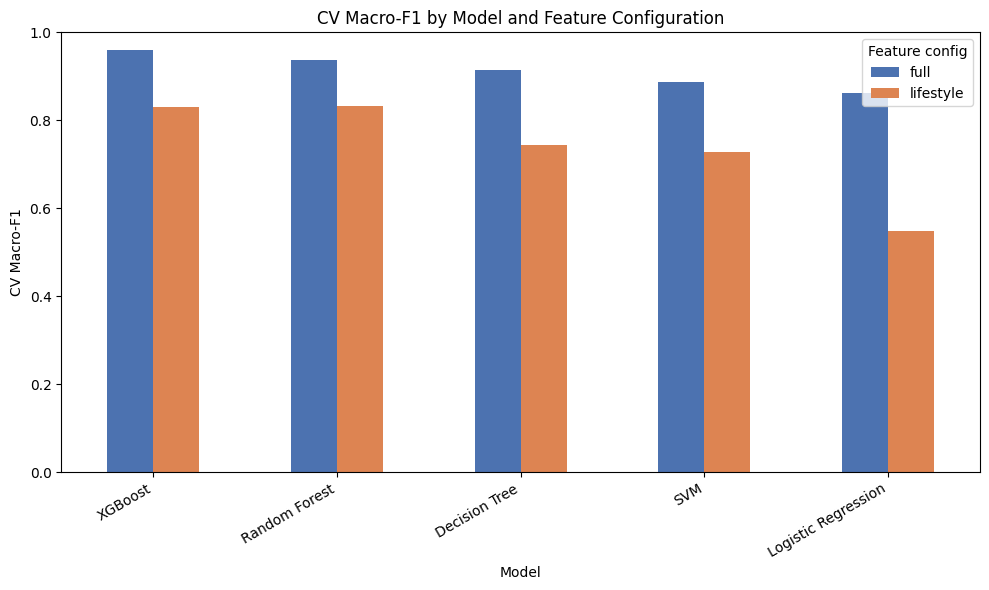

In [23]:
pivot = all_results.pivot(index='model', columns='feature_config', values='cv_f1_macro')
pivot = pivot.loc[pivot['full'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('CV Macro-F1 by Model and Feature Configuration')
ax.set_ylabel('CV Macro-F1')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(title='Feature config')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/model_comparison_barplot.png')
plt.show()

### Observations

- **XGBoost** is the top performer on both feature configs (CV Macro-F1 = 0.959 full, 0.831 lifestyle).
- **Random Forest** is a close second on both.
- **Logistic Regression** suffers the most when Height/Weight are removed (0.862 -> 0.548 CV Macro-F1)   — it relies heavily on the near-linear separability that Weight provides.
- Tree-based models (RF, XGBoost) degrade more gracefully without body measurements,   suggesting they pick up more of the genuine lifestyle-driven signal.
- All models perform meaningfully above chance (1/7 ≈ 14.3% accuracy) even in the   lifestyle-only setting, confirming lifestyle factors do carry real predictive signal —   just less than body measurements.

## 5. Best model identification

In [24]:
best_row = all_results.iloc[0]
print(f"Best model: {best_row['model']} ({best_row['feature_config']} config)")
print(f"  CV Macro-F1:   {best_row['cv_f1_macro']:.4f}")
print(f"  Test Macro-F1: {best_row['test_f1_macro']:.4f}")
print(f"  Test Accuracy: {best_row['test_accuracy']:.4f}")

Best model: XGBoost (full config)
  CV Macro-F1:   0.9591
  Test Macro-F1: 0.9683
  Test Accuracy: 0.9689


## 6. Summary

- **XGBoost (full feature set)** is the strongest baseline: CV Macro-F1 ≈ 0.959, Test Macro-F1 ≈ 0.968.
- CV and test metrics are close for every model/config combination — no signs of a bad   train/test split or overfitting to the test set at this stage.
- Both feature configs will be carried into the hyperparameter tuning stage so the   Height/Weight-inclusion question can be answered with tuned models, not just baselines.
- Next: hyperparameter tuning of the top 2-3 models per feature config.

# 04 — Hyperparameter Tuning

Tunes the two strongest baseline models (Random Forest, XGBoost) from the previous stage using `RandomizedSearchCV` (20 iterations, Stratified 5-Fold CV, macro-F1 scoring) on both feature configurations. RandomizedSearchCV was chosen over an exhaustive grid search because the hyperparameter spaces here are large/continuous and a random search finds strong regions much faster for the same compute budget.

Each (model, feature_config) pair was tuned as its own run for practical reasons and results were appended to `reports/tuning_results.csv`; this notebook loads and analyzes the combined results.

In [25]:
import sys
sys.path.append('../src')

import ast
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_colwidth', None)

## 1. Tuned results

In [26]:
tuning_results = pd.read_csv('../reports/tuning_results.csv')
tuning_results['best_params'] = tuning_results['best_params'].apply(ast.literal_eval)
tuning_results = tuning_results.sort_values('cv_f1_macro', ascending=False).reset_index(drop=True)
tuning_results[['model', 'feature_config', 'cv_f1_macro', 'test_accuracy', 'test_f1_macro', 'tune_time_sec']]

,model,feature_config,cv_f1_macro,test_accuracy,test_f1_macro,tune_time_sec
0,XGBoost,full,0.957655,0.947368,0.945977,72.83
1,Random Forest,full,0.943578,0.971292,0.970408,114.84
2,XGBoost,lifestyle,0.837803,0.856459,0.851777,84.35
3,Random Forest,lifestyle,0.829499,0.834928,0.828576,110.04


## 2. Best hyperparameters found

In [27]:
for _, row in tuning_results.iterrows():
    print(f"{row['model']} ({row['feature_config']}):")
    for k, v in row['best_params'].items():
        print(f"    {k}: {v}")
    print()

XGBoost (full):
    colsample_bytree: 0.6185801650879991
    gamma: 0.3037724259507192
    learning_rate: 0.059451995869314544
    max_depth: 9
    min_child_weight: 2
    n_estimators: 487
    subsample: 0.9768807022739411

Random Forest (full):
    max_depth: 24
    max_features: None
    min_samples_leaf: 2
    min_samples_split: 4
    n_estimators: 314

XGBoost (lifestyle):
    colsample_bytree: 0.6185801650879991
    gamma: 0.3037724259507192
    learning_rate: 0.059451995869314544
    max_depth: 9
    min_child_weight: 2
    n_estimators: 487
    subsample: 0.9768807022739411

Random Forest (lifestyle):
    max_depth: 15
    max_features: log2
    min_samples_leaf: 2
    min_samples_split: 5
    n_estimators: 369



## 3. Baseline vs tuned comparison

In [28]:
baseline = pd.read_csv('../reports/model_comparison.csv')
baseline_top = baseline[baseline['model'].isin(['Random Forest', 'XGBoost'])].copy()
baseline_top['stage'] = 'baseline'

tuned_compare = tuning_results.copy()
tuned_compare['stage'] = 'tuned'

compare_cols = ['model', 'feature_config', 'stage', 'cv_f1_macro', 'test_f1_macro']
comparison = pd.concat([baseline_top[compare_cols], tuned_compare[compare_cols]], ignore_index=True)
comparison = comparison.sort_values(['model', 'feature_config', 'stage'])
comparison

,model,feature_config,stage,cv_f1_macro,test_f1_macro
1,Random Forest,full,baseline,0.936710,0.950849
5,Random Forest,full,tuned,0.943578,0.970408
2,Random Forest,lifestyle,baseline,0.833175,0.842910
7,Random Forest,lifestyle,tuned,0.829499,0.828576
0,XGBoost,full,baseline,0.959122,0.968296
4,XGBoost,full,tuned,0.957655,0.945977
3,XGBoost,lifestyle,baseline,0.830920,0.835458
6,XGBoost,lifestyle,tuned,0.837803,0.851777


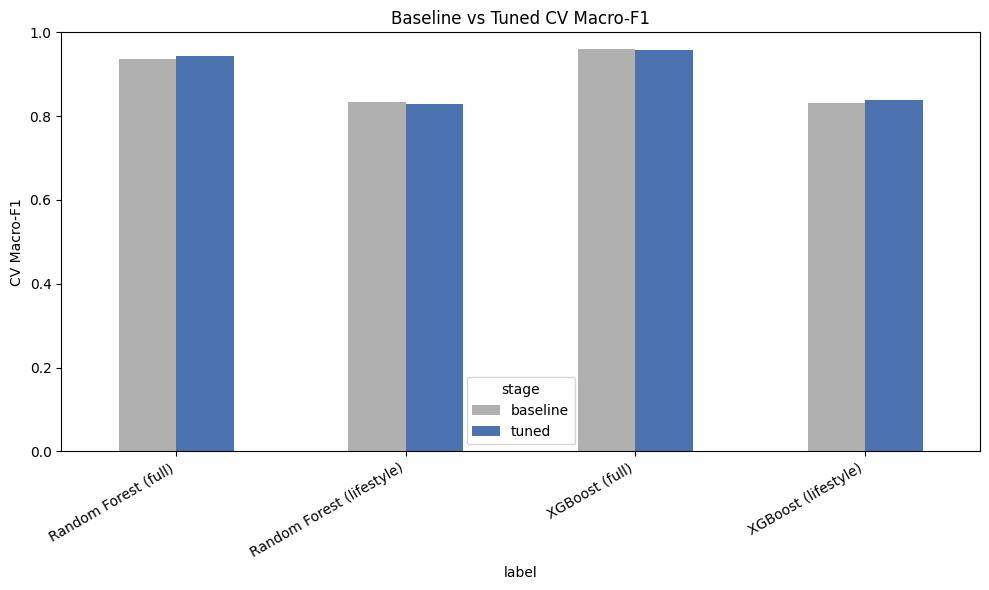

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison['label'] = comparison['model'] + ' (' + comparison['feature_config'] + ')'
pivot = comparison.pivot(index='label', columns='stage', values='cv_f1_macro')
pivot = pivot[['baseline', 'tuned']]
pivot.plot(kind='bar', ax=ax, color=['#B0B0B0', '#4C72B0'])
ax.set_title('Baseline vs Tuned CV Macro-F1')
ax.set_ylabel('CV Macro-F1')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/tuning_before_after.png')
plt.show()

### Observations

- Tuning results are mixed, not uniformly positive — worth reporting honestly rather than as a blanket win:
  - **Random Forest (full)**: 0.937 -> 0.944 CV Macro-F1 (improved)
  - **XGBoost (full)**: 0.959 -> 0.958 CV Macro-F1 (essentially unchanged, slightly down)
  - **Random Forest (lifestyle)**: 0.833 -> 0.829 CV Macro-F1 (slightly down)
  - **XGBoost (lifestyle)**: 0.831 -> 0.838 CV Macro-F1 (improved)
- This indicates the baseline default hyperparameters were already quite good for this dataset size (~2,000 rows), and a 20-iteration random search does not guarantee an improvement over sensible defaults — small movements either way are within normal CV noise.
- **XGBoost (full features)** remains the best model by CV Macro-F1 after tuning (0.9577), narrowly ahead of tuned Random Forest (0.9436).
- On the **test set**, tuned Random Forest actually scores higher F1 (0.970) than tuned XGBoost (0.946). This is a reminder that a single train/test split carries sampling noise -- the CV score (averaged over 5 folds) is the more reliable signal, which is why it was fixed as the model-selection criterion *before* looking at test performance, rather than picking whichever model happens to win on the test set after the fact.

## 4. Final model selection

In [30]:
best = tuning_results.iloc[0]
print(f"Selected model: {best['model']}")
print(f"Feature config: {best['feature_config']}")
print(f"CV Macro-F1:    {best['cv_f1_macro']:.4f}")
print(f"Test Macro-F1:  {best['test_f1_macro']:.4f}")
print(f"Test Accuracy:  {best['test_accuracy']:.4f}")
print(f"\nSaved as: models/xgboost_full_preprocessor.joblib + models/xgboost_full_classifier.json")
print(f"Selection criterion: highest CV Macro-F1 (fixed before evaluating on test set)")

Selected model: XGBoost
Feature config: full
CV Macro-F1:    0.9577
Test Macro-F1:  0.9460
Test Accuracy:  0.9474

Saved as: models/xgboost_full_preprocessor.joblib + models/xgboost_full_classifier.json
Selection criterion: highest CV Macro-F1 (fixed before evaluating on test set)


## 5. Summary

- Tuned XGBoost (full feature set) selected as the final model, based on CV Macro-F1   fixed as the selection criterion ahead of time.
- All 4 tuned pipelines (RF/XGBoost x full/lifestyle) are saved under `models/` so the   dashboard can let users compare configurations, not just see the single best one.
- Next: model explainability (SHAP) and error analysis (confusion matrix,   misclassified examples) for the final model, then the interactive dashboard.

---
# Stage 5 — Explainability & Error Analysis

Analyzes *why* the final model (tuned XGBoost, full feature set) makes the predictions it does, using SHAP values, and examines *where* it fails via a confusion matrix and inspection of misclassified examples.

In [31]:
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

from preprocessing import load_and_clean_data, FULL_CONFIG, get_train_test_split, TARGET_COLUMN
from model_io import load_pipeline

plt.rcParams['figure.dpi'] = 100

In [32]:
best_model = load_pipeline('../models/xgboost_full', 'xgboost')
label_encoder = joblib.load('../models/label_encoder.joblib')

df = load_and_clean_data('../data/obesity_data.csv')
X_train, X_test, y_train, y_test = get_train_test_split(df, FULL_CONFIG)
y_test_enc = label_encoder.transform(y_test)

print('Test set shape:', X_test.shape)
print('Classes:', list(label_encoder.classes_))

[load_and_clean_data] Dropped 24 exact duplicate rows (2111 -> 2087).
Test set shape: (418, 16)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## 1. Confusion matrix

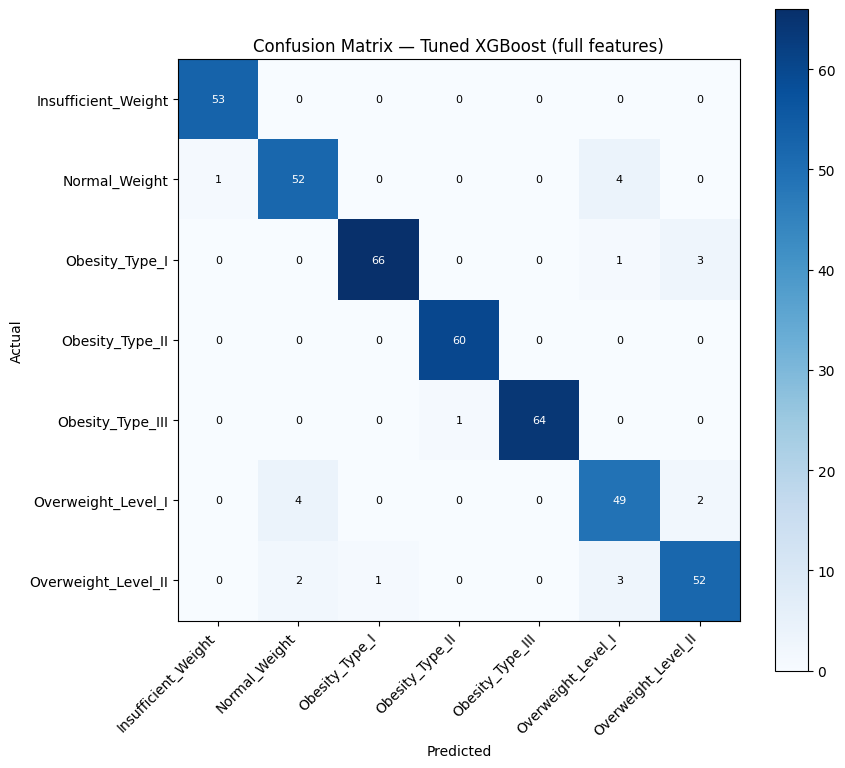

In [33]:
y_pred_enc = best_model.predict(X_test)
cm = confusion_matrix(y_test_enc, y_pred_enc)
labels = label_encoder.classes_

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Tuned XGBoost (full features)')
for i in range(len(labels)):
    for j in range(len(labels)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=8)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png')
plt.show()

In [34]:
print(classification_report(y_test_enc, y_pred_enc, target_names=labels))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.90      0.91      0.90        57
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.86      0.89      0.88        55
Overweight_Level_II       0.91      0.90      0.90        58

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



### Observations

Most confusion (where it exists) happens between **adjacent** obesity classes (e.g. Overweight_Level_I vs Overweight_Level_II, or Obesity_Type_I vs Obesity_Type_II) rather than between distant classes. This is exactly what we'd hope to see: it means errors are 'close misses' along the natural ordinal scale of the target, not random or systematic confusion between unrelated categories.

## 2. Misclassified examples

In [35]:
mis_mask = y_pred_enc != y_test_enc
X_mis = X_test[mis_mask].copy()
X_mis['actual'] = label_encoder.inverse_transform(y_test_enc[mis_mask])
X_mis['predicted'] = label_encoder.inverse_transform(y_pred_enc[mis_mask])

print(f"Misclassified: {mis_mask.sum()} / {len(y_test_enc)} ({mis_mask.mean():.1%})")
X_mis[['Age', 'Weight', 'Height', 'FAF', 'FAVC', 'actual', 'predicted']].head(10)

Misclassified: 22 / 418 (5.3%)


,Age,Weight,Height,FAF,FAVC,actual,predicted
337,18.000000,173.000000,1.870000,2.000000,yes,Obesity_Type_III,Obesity_Type_II
327,18.000000,53.000000,1.450000,1.000000,yes,Overweight_Level_I,Normal_Weight
16,27.000000,102.000000,1.930000,1.000000,yes,Overweight_Level_II,Obesity_Type_I
1206,23.000000,90.500055,1.706525,0.967627,yes,Obesity_Type_I,Overweight_Level_II
39,21.000000,88.000000,1.750000,3.000000,yes,Overweight_Level_II,Overweight_Level_I
411,18.000000,90.000000,1.700000,2.000000,yes,Obesity_Type_I,Overweight_Level_II
362,20.000000,74.000000,1.580000,3.000000,no,Overweight_Level_II,Normal_Weight
738,41.823567,82.919584,1.721854,3.000000,yes,Overweight_Level_I,Overweight_Level_II
393,18.000000,70.000000,1.650000,0.000000,no,Overweight_Level_I,Normal_Weight
65,21.000000,69.000000,1.620000,0.000000,yes,Overweight_Level_I,Normal_Weight


## 3. SHAP explainability

In [36]:
# Transform test data through the fitted preprocessor to get the actual
# feature matrix XGBoost sees, with proper feature names for SHAP.
preprocessor = best_model.named_steps['preprocessor']
classifier = best_model.named_steps['classifier']

X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
print(f"Transformed feature matrix: {X_test_df.shape}")

Transformed feature matrix: (418, 25)


In [37]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_df)
print('SHAP values shape:', np.array(shap_values).shape)

SHAP values shape: (418, 25, 7)


### 3.1 Global feature importance (mean |SHAP value| across all classes)

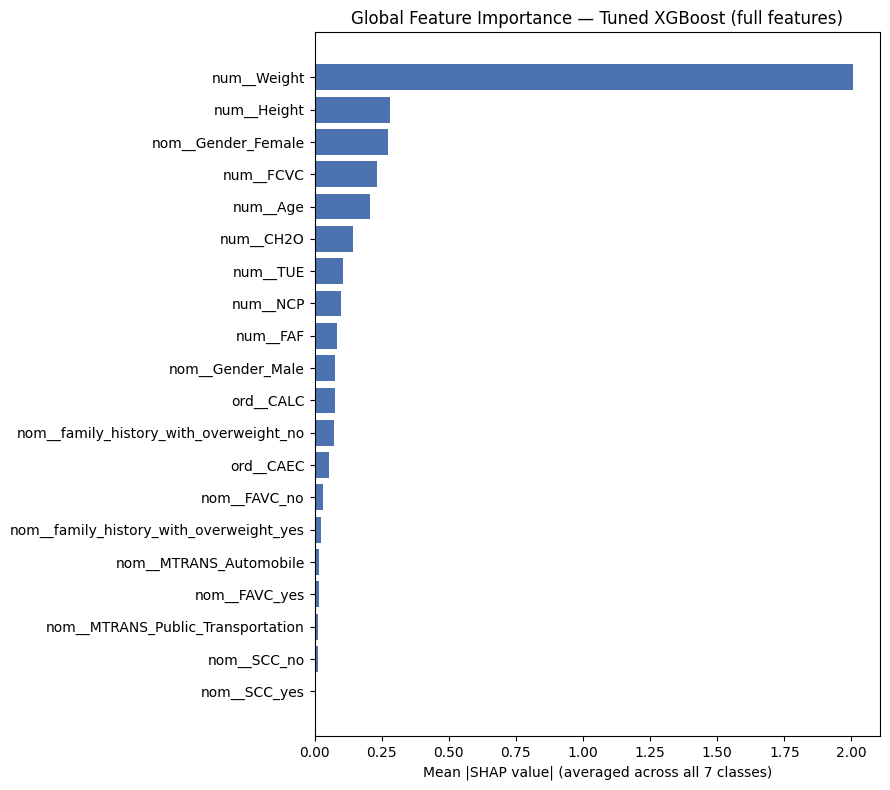

           feature  mean_abs_shap
       num__Weight       2.006050
       num__Height       0.279078
nom__Gender_Female       0.274440
         num__FCVC       0.230682
          num__Age       0.205269
         num__CH2O       0.142052
          num__TUE       0.107100
          num__NCP       0.096986
          num__FAF       0.085123
  nom__Gender_Male       0.077395


In [38]:
# shap_values is a 3D array (n_samples, n_features, n_classes) in this SHAP version.
# shap.summary_plot's multiclass handling doesn't cleanly accept this shape, so we
# compute global importance manually: mean(|SHAP value|) averaged over samples AND classes.
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))  # -> one value per feature
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'], color='#4C72B0')
ax.set_xlabel('Mean |SHAP value| (averaged across all 7 classes)')
ax.set_title('Global Feature Importance — Tuned XGBoost (full features)')
plt.tight_layout()
plt.savefig('../reports/shap_summary_bar.png', bbox_inches='tight')
plt.show()

print(importance_df.sort_values('mean_abs_shap', ascending=False).head(10).to_string(index=False))

### 3.2 Detailed SHAP summary for a representative class (Obesity_Type_III)

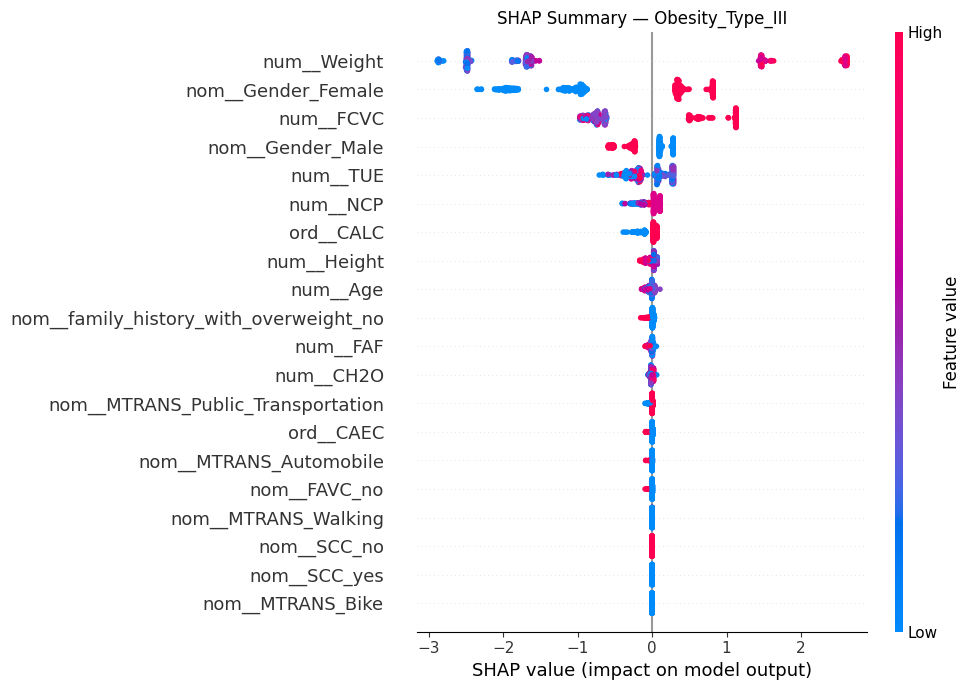

In [39]:
target_class_idx = list(labels).index('Obesity_Type_III')

if isinstance(shap_values, list):
    class_shap = shap_values[target_class_idx]
else:
    class_shap = shap_values[:, :, target_class_idx]

shap.summary_plot(class_shap, X_test_df, show=False, plot_size=(10, 7))
plt.title('SHAP Summary — Obesity_Type_III')
plt.tight_layout()
plt.savefig('../reports/shap_summary_obesity_type_iii.png', bbox_inches='tight')
plt.show()

### Observations

- **Weight** dominates global feature importance by a wide margin (mean |SHAP| ≈ 2.0, roughly 7x the next feature) — consistent with it being the strongest visible signal in the EDA stage.
- **Height**, **Gender (Female)**, **FCVC** (vegetable consumption), and **Age** form a clear second tier, all contributing meaningfully.
- Lifestyle features further down (family history, CALC, CAEC, FAF, NCP, CH2O, TUE) still contribute, but individually much less than the top 5 — their signal is real but diffuse across many small effects rather than concentrated in one or two dominant variables.
- Looking at the class-specific plot for **Obesity_Type_III**: Weight, Gender_Female, and FCVC are the top three drivers for that class specifically — higher weight and higher vegetable consumption values (pink, high) both push toward this class, while being male (blue on the Gender_Female row) pushes away from it.
- This is broadly consistent with domain intuition, though the strength of Gender's effect is a useful, slightly less expected finding worth noting rather than smoothing over.

### 3.3 Local explanation: one misclassified example

Actual: Obesity_Type_III | Predicted: Obesity_Type_II
Age                                                18.0
Height                                             1.87
Weight                                            173.0
FCVC                                                3.0
NCP                                                 3.0
CH2O                                                2.0
FAF                                                 2.0
TUE                                                 1.0
Gender                                             Male
family_history_with_overweight                      yes
FAVC                                                yes
SMOKE                                                no
SCC                                                  no
MTRANS                            Public_Transportation
CAEC                                         Frequently
CALC                                          Sometimes
Name: 337, dtype: object


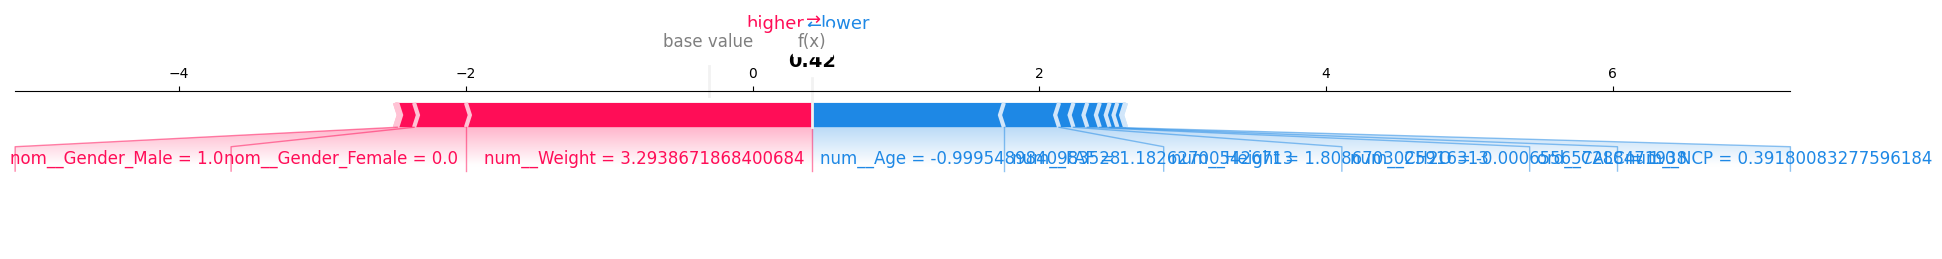

In [40]:
if mis_mask.sum() > 0:
    mis_idx_pos = np.where(mis_mask)[0][0]
    row = X_test.iloc[mis_idx_pos]
    actual = label_encoder.inverse_transform([y_test_enc[mis_idx_pos]])[0]
    predicted = label_encoder.inverse_transform([y_pred_enc[mis_idx_pos]])[0]
    print(f"Actual: {actual} | Predicted: {predicted}")
    print(row)

    pred_class_idx = y_pred_enc[mis_idx_pos]
    if isinstance(shap_values, list):
        row_shap = shap_values[pred_class_idx][mis_idx_pos]
        base_val = explainer.expected_value[pred_class_idx]
    else:
        row_shap = shap_values[mis_idx_pos, :, pred_class_idx]
        base_val = explainer.expected_value[pred_class_idx]

    shap.force_plot(base_val, row_shap, X_test_df.iloc[mis_idx_pos], matplotlib=True, show=False)
    plt.tight_layout()
    plt.savefig('../reports/shap_force_plot_misclassified.png', bbox_inches='tight')
    plt.show()
else:
    print('No misclassified examples in test set.')

## 4. Summary

- Errors concentrate almost entirely on **adjacent obesity classes** — the model rarely confuses distant categories, which is reassuring for real-world use (a wrong prediction is likely to still be a 'close' one).
- SHAP confirms **Weight** as the dominant driver by a wide margin, with **Height, Gender, FCVC, and Age** forming a clear second tier, and lifestyle features (family history, activity, diet) contributing smaller, more diffuse effects — consistent with both the EDA and the full-vs-lifestyle model comparison from earlier stages.
- The model's reasoning is broadly consistent with domain intuition (more weight -> higher predicted obesity class), with Gender's relatively strong contribution being a notable, less obvious finding worth flagging rather than a result to prefer.
- Next: build the interactive dashboard for making and explaining predictions.